<a href="https://colab.research.google.com/github/fronre/Big_Data_Intero/blob/main/URL_Bounis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 URL Analysis (Bonus Task)

This bonus experiment extends the MapReduce model to analyze web traffic at the page level.

🎯 Goal:
To determine the most visited URLs and evaluate user interaction with different pages.

🚀 Key Insight:
By changing the key from **status code → URL**, we can reuse the same MapReduce logic to answer a different analytical question.

👉 This demonstrates the flexibility and power of the MapReduce paradigm.

In [2]:
%%writefile weblogs.txt
# Date, Time, IP, Method, URL, Status, ResponseSize
2025-10-10,12:01:32,192.168.1.2,GET,/index.html,200,1024
2025-10-10,12:01:33,192.168.1.3,GET,/products.html,200,850
2025-10-10,12:01:35,192.168.1.4,GET,/contact.html,404,512
2025-10-10,12:01:38,192.168.1.5,POST,/checkout,500,128
2025-10-10,12:01:41,192.168.1.6,GET,/index.html,200,1024
2025-10-10,12:01:45,192.168.1.7,GET,/images/logo.png,200,256
2025-10-10,12:01:48,192.168.1.8,GET,/about.html,404,512
2025-10-10,12:01:53,192.168.1.9,POST,/login,403,64
2025-10-10,12:02:01,192.168.1.10,GET,/index.html,200,1024
2025-10-10,12:02:07,192.168.1.11,POST,/checkout,500,128
2025-10-10,12:02:12,192.168.1.12,GET,/contact.html,404,512
2025-10-10,12:02:15,192.168.1.13,GET,/index.html,200,1024
2025-10-10,12:02:21,192.168.1.14,GET,/products.html,200,850
2025-10-10,12:02:23,192.168.1.15,GET,/about.html,404,512
2025-10-10,12:02:29,192.168.1.16,POST,/checkout,500,128
2025-10-10,12:02:31,192.168.1.17,GET,/images/logo.png,200,256
2025-10-10,12:02:34,192.168.1.18,GET,/contact.html,404,512
2025-10-10,12:02:38,192.168.1.19,POST,/login,403,64
2025-10-10,12:02:41,192.168.1.20,GET,/index.html,200,1024
2025-10-10,12:02:47,192.168.1.21,GET,/products.html,200,850

Overwriting weblogs.txt


# Mapper

In [3]:
def mapper(line):
    fields = line.strip().split(",")
    if len(fields) != 7 or fields[0].startswith('#'):
        return []
    url = fields[4]
    return [(url, 1)]

# Shuffle **Phase**

In [4]:
from collections import defaultdict

def shuffle(mapped_data):
    grouped = defaultdict(list)
    for key, value in mapped_data:
        grouped[key].append(value)
    return grouped

# Reducer **Phase**

In [5]:
def reducer(grouped_data):
    result = {}
    for key, values in grouped_data.items():
        result[key] = sum(values)
    return result

# Combine the **Phases**

In [6]:
mapped = []

with open("weblogs.txt", "r") as f:
    for line in f:
        mapped.extend(mapper(line))

grouped = shuffle(mapped)
reduced = reducer(grouped)

print("=== Requests per URL ===")
for url, count in sorted(reduced.items(), key=lambda x: x[1], reverse=True):
    print(f"{url}: {count} requests")

=== Requests per URL ===
/index.html: 5 requests
/products.html: 3 requests
/contact.html: 3 requests
/checkout: 3 requests
/images/logo.png: 2 requests
/about.html: 2 requests
/login: 2 requests


In [7]:
print("\n=== Top 3 Most Visited Pages ===")

top3 = sorted(reduced.items(), key=lambda x: x[1], reverse=True)[:3]

for url, count in top3:
    print(f"{url}: {count} requests")


=== Top 3 Most Visited Pages ===
/index.html: 5 requests
/products.html: 3 requests
/contact.html: 3 requests


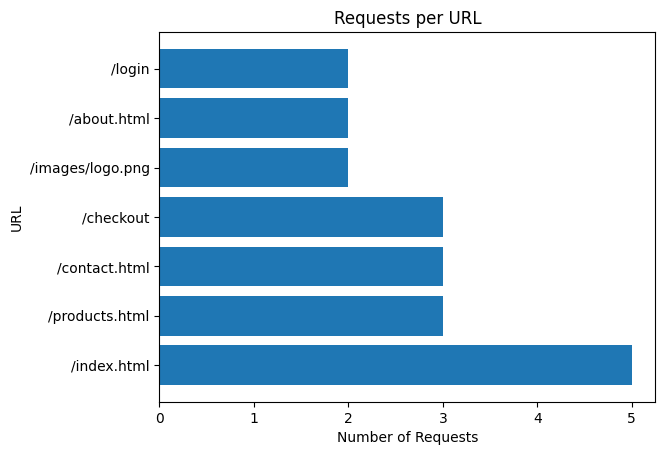

In [8]:
import matplotlib.pyplot as plt

urls = list(reduced.keys())
counts = list(reduced.values())

plt.barh(urls, counts)
plt.title("Requests per URL")
plt.xlabel("Number of Requests")
plt.ylabel("URL")
plt.show()